# Tiny Graphs - Neural Network (Single MLP)

Each graph section is self-contained and can be run independently: config -> train/load -> evaluation -> embeddings/edges -> reduction -> raw plot -> styled plot -> evolution -> heatmap -> line plot.


## 1) Tiny Path-Star (deg=4, deg_tree=1, path_len=5)


In [1]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [2]:
path_star_seed = 7

path_star_train_from_scratch = True
path_star_checkpoint_path = ""
path_star_embedding_history_path = ""
path_star_topk_history_path = ""
path_star_dataset_overwrite = False

path_star_cli_config = {
    "--training_recipe": "staged_full_path", 
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.05,
    "--edge_memorization_epochs": 1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 32,
    "--optimizer_weight_decay": 0.001,
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0.,
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,

    "--graph_type": "star",
    "--star_degree": 4,
    "--star_subtree_degree": 1,
    "--path_length": 5,
    "--total_nodes": -1,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
}


In [3]:
path_star_context = build_transformer_section_context(
    path_star_cli_config,
    seed=path_star_seed,
    dataset_overwrite=path_star_dataset_overwrite,
)

path_star_resolved_checkpoint_path = train_or_load_edge_model(
    path_star_context,
    train_from_scratch=path_star_train_from_scratch,
    checkpoint_path=path_star_checkpoint_path,
)

print("Run name:", path_star_context.args.run_name)
print("Checkpoint:", path_star_resolved_checkpoint_path)
print("Pretrain file:", path_star_context.pretrain_path)
print("Train file:", path_star_context.train_path)
print("Test file:", path_star_context.test_path)
print("Archived checkpoint:", path_star_context.checkpoint_path)
print("Embedding history pickle:", path_star_context.embedding_history_path)
print("Top-k pickle:", path_star_context.topk_history_path)
print("Manifest:", path_star_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
data/datasets/in_weights_graphs/star_graphs_randomized/star_deg_4_deg_tree_1_path_5_nodes_17_sd_00_fb_11_pretrain.txt
data/datasets/in_weights_graphs/star_graphs_randomized/star_deg_4_deg_tree_1_path_5_nodes_17_sd_00_fb_11_train_3.txt
data/datasets/in_weights_graphs/star_graphs_randomized/star_deg_4_deg_tree_1_path_5_nodes_17_sd_00_fb_11_test_1.txt
Loaded 32 edge memorization pairs from data/datasets/in_weights_graphs/star_graphs_randomized/star_deg_4_deg_tree_1_path_5_nodes_17_sd_00_fb_11_pretrain.txt
Equal sequence lengths!
Edge memorization dataset size: 32
Edge dataset tokens -> prefix=2, target=1
Loaded 3 path finetuning pairs from data/datasets/in_weights_graphs/star_graphs_randomized/star_deg_4_deg_tree_1_path_5_nodes_17_sd_00_fb_11_train_3.txt
Equal sequence lengths!
Path finetuning dataset size: 3
Path dataset tokens -> pre

Edge Epoch 1/1000 | Loss: 3.2598 | Acc: 0.00%: 100%|██████████| 1/1 [00:00<00:00,  2.13it/s]
Edge Epoch 2/1000 | Loss: 2.9326 | Acc: 12.50%: 100%|██████████| 1/1 [00:00<00:00, 103.86it/s]
Edge Epoch 3/1000 | Loss: 4.2327 | Acc: 12.50%: 100%|██████████| 1/1 [00:00<00:00, 105.88it/s]
Edge Epoch 4/1000 | Loss: 3.2892 | Acc: 6.25%: 100%|██████████| 1/1 [00:00<00:00, 90.29it/s]
Edge Epoch 5/1000 | Loss: 2.9370 | Acc: 6.25%: 100%|██████████| 1/1 [00:00<00:00, 88.87it/s]
Edge Epoch 6/1000 | Loss: 2.9717 | Acc: 6.25%: 100%|██████████| 1/1 [00:00<00:00, 102.17it/s]
Edge Epoch 7/1000 | Loss: 2.8931 | Acc: 12.50%: 100%|██████████| 1/1 [00:00<00:00, 100.33it/s]
Edge Epoch 8/1000 | Loss: 2.9202 | Acc: 12.50%: 100%|██████████| 1/1 [00:00<00:00, 100.64it/s]
Edge Epoch 9/1000 | Loss: 2.8413 | Acc: 12.50%: 100%|██████████| 1/1 [00:00<00:00, 77.45it/s]
Edge Epoch 10/1000 | Loss: 2.8066 | Acc: 12.50%: 100%|██████████| 1/1 [00:00<00:00, 118.70it/s]
Edge Epoch 11/1000 | Loss: 2.8154 | Acc: 6.25%: 100%|████


Edge accuracy improved to 53.12%. Saved best checkpoint: experiment_logs/in_weights/in_weights_star-d4-dt1-p5-n17_gpt-L1-D32-H1_tiny_star_feedforward_plain_edge_bs2048x2048-lr0p05x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101106/checkpoints/in_weights_star-d4-dt1-p5-n17_gpt-L1-D32-H1_tiny_star_feedforward_plain_edge_bs2048x2048-lr0p05x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101106_edge_memorization_best.pt


Edge Epoch 1000/1000 | Loss: 0.6956 | Acc: 53.12%: 100%|██████████| 1/1 [00:00<00:00, 93.06it/s]



Edge memorization complete. Best edge accuracy: 53.12%
Run name: in_weights_star-d4-dt1-p5-n17_gpt-L1-D32-H1_tiny_star_feedforward_plain_edge_bs2048x2048-lr0p05x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101106
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/star/in_weights_star-d4-dt1-p5-n17_gpt-L1-D32-H1_tiny_star_feedforward_plain_edge_bs2048x2048-lr0p05x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101106_edge_memorization_final.pt
Pretrain file: data/datasets/in_weights_graphs/star_graphs_randomized/star_deg_4_deg_tree_1_path_5_nodes_17_sd_00_fb_11_pretrain.txt
Train file: data/datasets/in_weights_graphs/star_graphs_randomized/star_deg_4_deg_tree_1_path_5_nodes_17_sd_00_fb_11_train_3.txt
Test file: data/datasets/in_weights_graphs/star_graphs_randomized/star_deg_4_deg_tree_1_path_5_nodes_17_sd_00_fb_11_test_1.txt
Archived checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_ar

In [4]:
path_star_eval_metrics = evaluate_edge_and_path(path_star_context)

print_evaluation_report("Tiny Path-Star", path_star_eval_metrics)


Edge Memorization | Loss: 0.6964 | Acc: 53.12%: 100%|██████████| 1/1 [00:00<00:00, 112.78it/s]


Edge Memorization | Loss: 0.6964 | Acc: 53.12%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 127.38it/s]

Tiny Path-Star | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [5]:
path_star_node_embeddings, path_star_edge_list, path_star_root_node_index = collect_embeddings_and_edges(path_star_context)

path_star_embedding_history, path_star_topk_recovery_history = load_analysis_histories(
    path_star_context,
    path_star_edge_list,
    embedding_history_path=path_star_embedding_history_path,
    topk_history_path=path_star_topk_history_path,
)

if not path_star_embedding_history:
    path_star_embedding_history = {0: path_star_node_embeddings}
if not path_star_topk_recovery_history:
    path_star_topk_recovery_history = {0: path_star_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", path_star_node_embeddings.shape)
print("Number of edges:", len(path_star_edge_list))
print("Root node index:", path_star_root_node_index)
print("Embedding history steps:", len(path_star_embedding_history))
print("Top-k history steps:", len(path_star_topk_recovery_history))


Node embedding shape: (17, 32)
Number of edges: 32
Root node index: 3
Embedding history steps: 1000
Top-k history steps: 1000


In [6]:
# Reduction config for this block (kept local to reduction stage)
path_star_use_umap = False
path_star_reduction_dim = 4
path_star_umap_n_neighbors = 5
path_star_umap_min_dist = 0.3

path_star_reduced_full, path_star_reduced_embeddings = reduce_embeddings_for_plot(
    path_star_node_embeddings,
    use_umap=path_star_use_umap,
    reduction_dim=path_star_reduction_dim,
    seed=path_star_seed,
    umap_n_neighbors=path_star_umap_n_neighbors,
    umap_min_dist=path_star_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
path_star_reduced_embeddings = path_star_reduced_full[:, 1:]
print("Reduced full shape:", path_star_reduced_full.shape)
print("Reduced xyz shape:", path_star_reduced_embeddings.shape)


Reduced full shape: (17, 4)
Reduced xyz shape: (17, 3)


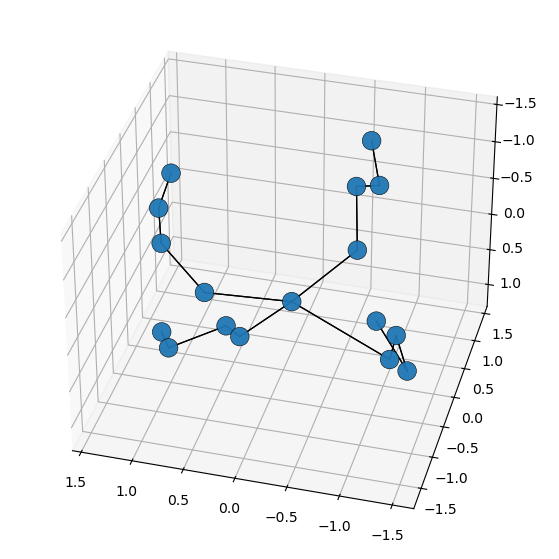

In [7]:
# %matplotlib widget
%matplotlib inline

# Raw plotting constants for this block
path_star_raw_elev = -35
path_star_raw_azim = -105
path_star_raw_roll = -180
path_star_raw_axis_permutation = (0, 1, 2)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

_xi, _yi, _zi = path_star_raw_axis_permutation
ax.scatter(
    path_star_reduced_embeddings[:, _xi],
    path_star_reduced_embeddings[:, _yi],
    path_star_reduced_embeddings[:, _zi],
    s=180,
    alpha=0.95,
    edgecolor='black',
    linewidth=0.4,
)

for u, v in path_star_edge_list:
    ax.plot(
        [path_star_reduced_embeddings[u, _xi], path_star_reduced_embeddings[v, _xi]],
        [path_star_reduced_embeddings[u, _yi], path_star_reduced_embeddings[v, _yi]],
        [path_star_reduced_embeddings[u, _zi], path_star_reduced_embeddings[v, _zi]],
        color='k',
        linewidth=0.9,
    )

ax.view_init(elev=float(path_star_raw_elev), azim=float(path_star_raw_azim), roll=float(path_star_raw_roll))
plt.title("")
plt.show()


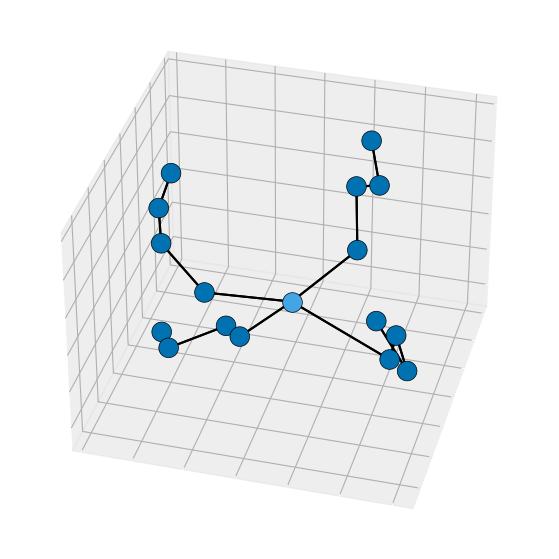

In [8]:
# Styled plotting constants for this block
path_star_styled_view = {"elev": path_star_raw_elev, "azim": path_star_raw_azim, "roll": path_star_raw_roll}
path_star_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    path_star_reduced_embeddings,
    path_star_edge_list,
    title="",
    view=path_star_styled_view,
    root_node_index=path_star_root_node_index,
    axis_permutation=path_star_styled_axis_permutation,
);


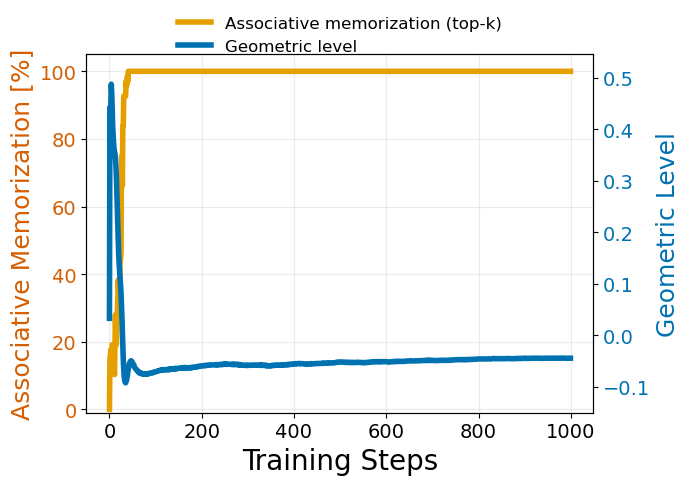

In [9]:
# Line-plot constants for this block
path_star_line_plot_title = ""

path_star_curve_steps, path_star_curve_associative, path_star_curve_geometric = compute_associative_geometric_curves(
    path_star_embedding_history,
    path_star_topk_recovery_history,
    path_star_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=path_star_curve_steps,
    associative_scores=path_star_curve_associative,
    geometric_scores=path_star_curve_geometric,
    title=path_star_line_plot_title,
);


## 2) Tiny Grid (rows=4, cols=4)


In [10]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [11]:
grid_seed = 7

grid_train_from_scratch = True
grid_checkpoint_path = ""
grid_embedding_history_path = ""
grid_topk_history_path = ""
grid_dataset_overwrite = False

grid_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.1,
    "--edge_memorization_epochs": 1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 16,
    "--optimizer_weight_decay": 0.,
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0.,
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,

    "--graph_type": "grid",
    "--grid_rows": 4,
    "--grid_cols": 4,
    "--path_length": 5,
    "--total_nodes": -1,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
}


In [12]:
grid_context = build_transformer_section_context(
    grid_cli_config,
    seed=grid_seed,
    dataset_overwrite=grid_dataset_overwrite,
)

grid_resolved_checkpoint_path = train_or_load_edge_model(
    grid_context,
    train_from_scratch=grid_train_from_scratch,
    checkpoint_path=grid_checkpoint_path,
)

print("Run name:", grid_context.args.run_name)
print("Checkpoint:", grid_resolved_checkpoint_path)
print("Pretrain file:", grid_context.pretrain_path)
print("Train file:", grid_context.train_path)
print("Test file:", grid_context.test_path)
print("Archived checkpoint:", grid_context.checkpoint_path)
print("Embedding history pickle:", grid_context.embedding_history_path)
print("Top-k pickle:", grid_context.topk_history_path)
print("Manifest:", grid_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_pretrain.txt
data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_train_12.txt
data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_test_4.txt
Loaded 48 edge memorization pairs from data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_pretrain.txt
Equal sequence lengths!
Edge memorization dataset size: 48
Edge dataset tokens -> prefix=2, target=1
Loaded 12 path finetuning pairs from data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_train_12.txt
Equal sequence lengths!
Path finetuning dataset size: 12
Path dataset tokens -> prefix=3, target=6
Loaded 4 path finetuning pairs

Edge Epoch 1/1000 | Loss: 3.2184 | Acc: 6.25%: 100%|██████████| 1/1 [00:00<00:00, 56.27it/s]
Edge Epoch 2/1000 | Loss: 3.1198 | Acc: 4.17%: 100%|██████████| 1/1 [00:00<00:00, 72.93it/s]
Edge Epoch 3/1000 | Loss: 2.9870 | Acc: 6.25%: 100%|██████████| 1/1 [00:00<00:00, 77.83it/s]
Edge Epoch 4/1000 | Loss: 3.3763 | Acc: 8.33%: 100%|██████████| 1/1 [00:00<00:00, 70.96it/s]
Edge Epoch 5/1000 | Loss: 3.0104 | Acc: 6.25%: 100%|██████████| 1/1 [00:00<00:00, 89.79it/s]
Edge Epoch 6/1000 | Loss: 3.4896 | Acc: 4.17%: 100%|██████████| 1/1 [00:00<00:00, 99.17it/s]
Edge Epoch 7/1000 | Loss: 2.8258 | Acc: 6.25%: 100%|██████████| 1/1 [00:00<00:00, 76.55it/s]
Edge Epoch 8/1000 | Loss: 2.8753 | Acc: 8.33%: 100%|██████████| 1/1 [00:00<00:00, 84.36it/s]
Edge Epoch 9/1000 | Loss: 2.8971 | Acc: 8.33%: 100%|██████████| 1/1 [00:00<00:00, 92.31it/s]
Edge Epoch 10/1000 | Loss: 2.8294 | Acc: 8.33%: 100%|██████████| 1/1 [00:00<00:00, 93.95it/s]
Edge Epoch 11/1000 | Loss: 2.8047 | Acc: 6.25%: 100%|██████████| 1/1 


Edge accuracy improved to 33.33%. Saved best checkpoint: experiment_logs/in_weights/in_weights_grid-r4-c4-n16_gpt-L1-D16-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p1x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101119/checkpoints/in_weights_grid-r4-c4-n16_gpt-L1-D16-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p1x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101119_edge_memorization_best.pt


Edge Epoch 1000/1000 | Loss: 1.1319 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 63.03it/s]



Edge memorization complete. Best edge accuracy: 33.33%
Run name: in_weights_grid-r4-c4-n16_gpt-L1-D16-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p1x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101119
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/grid/in_weights_grid-r4-c4-n16_gpt-L1-D16-H1_tiny_grid_feedforward_plain_edge_bs2048x2048-lr0p1x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101119_edge_memorization_final.pt
Pretrain file: data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_pretrain.txt
Train file: data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_train_12.txt
Test file: data/datasets/in_weights_graphs/grid_graphs_randomized/grid_rows_4_cols_4_nodes_16_sd_00_fb_11_test_4.txt
Archived checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/grid/in_weights_gri

In [37]:
grid_eval_metrics = evaluate_edge_and_path(grid_context)

print_evaluation_report("Tiny Grid", grid_eval_metrics)


Edge Memorization | Loss: 1.1299 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 48.97it/s]


Edge Memorization | Loss: 1.1299 | Acc: 33.33%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 59.38it/s]

Tiny Grid | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [14]:
grid_node_embeddings, grid_edge_list, grid_root_node_index = collect_embeddings_and_edges(grid_context)

grid_embedding_history, grid_topk_recovery_history = load_analysis_histories(
    grid_context,
    grid_edge_list,
    embedding_history_path=grid_embedding_history_path,
    topk_history_path=grid_topk_history_path,
)

if not grid_embedding_history:
    grid_embedding_history = {0: grid_node_embeddings}
if not grid_topk_recovery_history:
    grid_topk_recovery_history = {0: grid_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", grid_node_embeddings.shape)
print("Number of edges:", len(grid_edge_list))
print("Root node index:", grid_root_node_index)
print("Embedding history steps:", len(grid_embedding_history))
print("Top-k history steps:", len(grid_topk_recovery_history))


Node embedding shape: (16, 16)
Number of edges: 48
Root node index: None
Embedding history steps: 1000
Top-k history steps: 1000


In [15]:
# Reduction config for this block (kept local to reduction stage)
grid_use_umap = False
grid_reduction_dim = 5
grid_umap_n_neighbors = 4
grid_umap_min_dist = 0.3

grid_reduced_full, grid_reduced_embeddings = reduce_embeddings_for_plot(
    grid_node_embeddings,
    use_umap=grid_use_umap,
    reduction_dim=grid_reduction_dim,
    seed=grid_seed,
    umap_n_neighbors=grid_umap_n_neighbors,
    umap_min_dist=grid_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
grid_reduced_embeddings = grid_reduced_full[:, :3]
print("Reduced full shape:", grid_reduced_full.shape)
print("Reduced xyz shape:", grid_reduced_embeddings.shape)


Reduced full shape: (16, 5)
Reduced xyz shape: (16, 3)


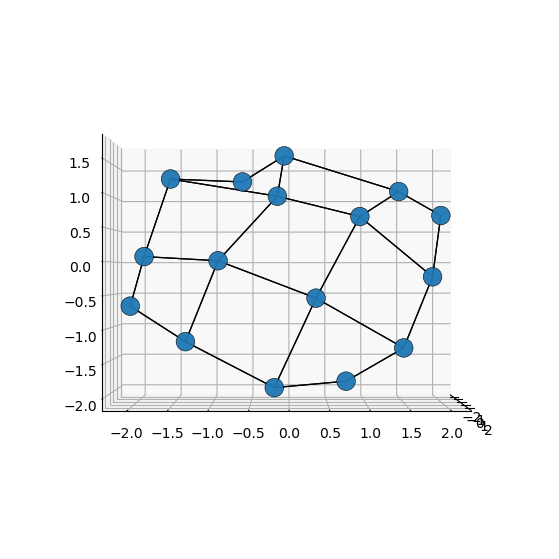

In [16]:
%matplotlib inline
# %matplotlib widget

# Raw plotting constants for this block
grid_raw_elev = 0
grid_raw_azim = 0
grid_raw_roll = 0
grid_raw_axis_permutation = (0, 1, 2)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

_xi, _yi, _zi = grid_raw_axis_permutation
ax.scatter(
    grid_reduced_embeddings[:, _xi],
    grid_reduced_embeddings[:, _yi],
    grid_reduced_embeddings[:, _zi],
    s=180,
    alpha=0.95,
    edgecolor='black',
    linewidth=0.4,
)

for u, v in grid_edge_list:
    ax.plot(
        [grid_reduced_embeddings[u, _xi], grid_reduced_embeddings[v, _xi]],
        [grid_reduced_embeddings[u, _yi], grid_reduced_embeddings[v, _yi]],
        [grid_reduced_embeddings[u, _zi], grid_reduced_embeddings[v, _zi]],
        color='k',
        linewidth=0.9,
    )

ax.view_init(elev=float(grid_raw_elev), azim=float(grid_raw_azim), roll=float(grid_raw_roll))
plt.title("")
plt.show()


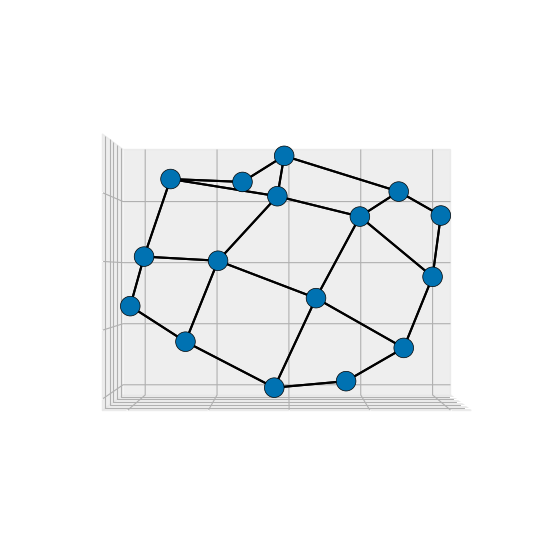

In [17]:
# Styled plotting constants for this block
grid_styled_view = {"elev": grid_raw_elev, "azim": grid_raw_azim, "roll": grid_raw_roll}
grid_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    grid_reduced_embeddings,
    grid_edge_list,
    title="",
    view=grid_styled_view,
    root_node_index=grid_root_node_index,
    axis_permutation=grid_styled_axis_permutation,
);


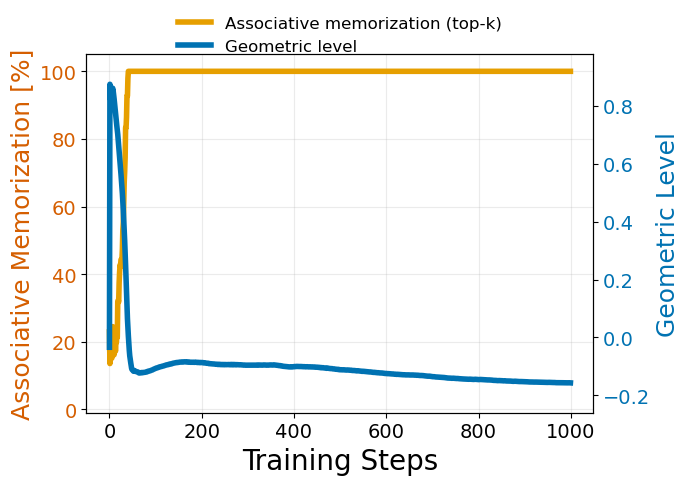

In [18]:
# Line-plot constants for this block
grid_line_plot_title = ""

grid_curve_steps, grid_curve_associative, grid_curve_geometric = compute_associative_geometric_curves(
    grid_embedding_history,
    grid_topk_recovery_history,
    grid_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=grid_curve_steps,
    associative_scores=grid_curve_associative,
    geometric_scores=grid_curve_geometric,
    title=grid_line_plot_title,
);


## 3) Tiny Cycle (N=15)


In [19]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [20]:
cycle_seed = 7

cycle_train_from_scratch = True
cycle_checkpoint_path = ""
cycle_embedding_history_path = ""
cycle_topk_history_path = ""
cycle_dataset_overwrite = False

cycle_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.05,
    "--edge_memorization_epochs": 1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 15,
    "--optimizer_weight_decay": 0.001,
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0.,
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,

    "--graph_type": "cycle",
    "--path_length": 5,
    "--total_nodes": 15,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
}


In [21]:
cycle_context = build_transformer_section_context(
    cycle_cli_config,
    seed=cycle_seed,
    dataset_overwrite=cycle_dataset_overwrite,
)

cycle_resolved_checkpoint_path = train_or_load_edge_model(
    cycle_context,
    train_from_scratch=cycle_train_from_scratch,
    checkpoint_path=cycle_checkpoint_path,
)

print("Run name:", cycle_context.args.run_name)
print("Checkpoint:", cycle_resolved_checkpoint_path)
print("Pretrain file:", cycle_context.pretrain_path)
print("Train file:", cycle_context.train_path)
print("Test file:", cycle_context.test_path)
print("Archived checkpoint:", cycle_context.checkpoint_path)
print("Embedding history pickle:", cycle_context.embedding_history_path)
print("Top-k pickle:", cycle_context.topk_history_path)
print("Manifest:", cycle_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_pretrain.txt
data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_train_11.txt
data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_test_4.txt
Loaded 30 edge memorization pairs from data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_pretrain.txt
Equal sequence lengths!
Edge memorization dataset size: 30
Edge dataset tokens -> prefix=2, target=1
Loaded 11 path finetuning pairs from data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_train_11.txt
Equal sequence lengths!
Path finetuning dataset size: 11
Path dataset tokens -> prefix=3, target=5
Loaded 4 path finetuning pairs from data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

Edge Epoch 1/1000 | Loss: 3.1760 | Acc: 3.33%: 100%|██████████| 1/1 [00:00<00:00, 44.86it/s]
Edge Epoch 2/1000 | Loss: 3.1771 | Acc: 6.67%: 100%|██████████| 1/1 [00:00<00:00, 102.22it/s]
Edge Epoch 3/1000 | Loss: 2.8068 | Acc: 6.67%: 100%|██████████| 1/1 [00:00<00:00, 87.78it/s]
Edge Epoch 4/1000 | Loss: 2.7250 | Acc: 6.67%: 100%|██████████| 1/1 [00:00<00:00, 130.75it/s]
Edge Epoch 5/1000 | Loss: 2.7161 | Acc: 6.67%: 100%|██████████| 1/1 [00:00<00:00, 120.69it/s]
Edge Epoch 6/1000 | Loss: 2.7229 | Acc: 6.67%: 100%|██████████| 1/1 [00:00<00:00, 131.52it/s]
Edge Epoch 7/1000 | Loss: 2.7385 | Acc: 6.67%: 100%|██████████| 1/1 [00:00<00:00, 115.54it/s]
Edge Epoch 8/1000 | Loss: 2.7562 | Acc: 6.67%: 100%|██████████| 1/1 [00:00<00:00, 112.27it/s]
Edge Epoch 9/1000 | Loss: 2.7750 | Acc: 6.67%: 100%|██████████| 1/1 [00:00<00:00, 110.69it/s]
Edge Epoch 10/1000 | Loss: 2.7667 | Acc: 3.33%: 100%|██████████| 1/1 [00:00<00:00, 114.21it/s]
Edge Epoch 11/1000 | Loss: 2.7625 | Acc: 6.67%: 100%|████████


Edge accuracy improved to 50.00%. Saved best checkpoint: experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D15-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p05x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101133/checkpoints/in_weights_cycle-n15_gpt-L1-D15-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p05x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101133_edge_memorization_best.pt


Edge Epoch 1000/1000 | Loss: 0.6953 | Acc: 50.00%: 100%|██████████| 1/1 [00:00<00:00, 101.21it/s]



Edge memorization complete. Best edge accuracy: 50.00%
Run name: in_weights_cycle-n15_gpt-L1-D15-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p05x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101133
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/cycle/in_weights_cycle-n15_gpt-L1-D15-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p05x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101133_edge_memorization_final.pt
Pretrain file: data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_pretrain.txt
Train file: data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_train_11.txt
Test file: data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_test_4.txt
Archived checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/cycle/in_weights_cycle-n15_gpt-L1-D15-H1_tiny_cycle_feedforward_plain_ed

In [38]:
cycle_eval_metrics = evaluate_edge_and_path(cycle_context)

print_evaluation_report("Tiny Cycle", cycle_eval_metrics)


Edge Memorization | Loss: 0.6951 | Acc: 50.00%: 100%|██████████| 1/1 [00:00<00:00, 99.58it/s]


Edge Memorization | Loss: 0.6951 | Acc: 50.00%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 86.91it/s]

Tiny Cycle | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [23]:
cycle_node_embeddings, cycle_edge_list, cycle_root_node_index = collect_embeddings_and_edges(cycle_context)

cycle_embedding_history, cycle_topk_recovery_history = load_analysis_histories(
    cycle_context,
    cycle_edge_list,
    embedding_history_path=cycle_embedding_history_path,
    topk_history_path=cycle_topk_history_path,
)

if not cycle_embedding_history:
    cycle_embedding_history = {0: cycle_node_embeddings}
if not cycle_topk_recovery_history:
    cycle_topk_recovery_history = {0: cycle_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", cycle_node_embeddings.shape)
print("Number of edges:", len(cycle_edge_list))
print("Root node index:", cycle_root_node_index)
print("Embedding history steps:", len(cycle_embedding_history))
print("Top-k history steps:", len(cycle_topk_recovery_history))


Node embedding shape: (15, 15)
Number of edges: 30
Root node index: None
Embedding history steps: 1000
Top-k history steps: 1000


In [24]:
# Reduction config for this block (kept local to reduction stage)
cycle_use_umap = False
cycle_reduction_dim = 4
cycle_umap_n_neighbors = 8
cycle_umap_min_dist = 0.3

cycle_reduced_full, cycle_reduced_embeddings = reduce_embeddings_for_plot(
    cycle_node_embeddings,
    use_umap=cycle_use_umap,
    reduction_dim=cycle_reduction_dim,
    seed=cycle_seed,
    umap_n_neighbors=cycle_umap_n_neighbors,
    umap_min_dist=cycle_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
cycle_reduced_embeddings = cycle_reduced_full[:, :3]
print("Reduced full shape:", cycle_reduced_full.shape)
print("Reduced xyz shape:", cycle_reduced_embeddings.shape)


Reduced full shape: (15, 4)
Reduced xyz shape: (15, 3)


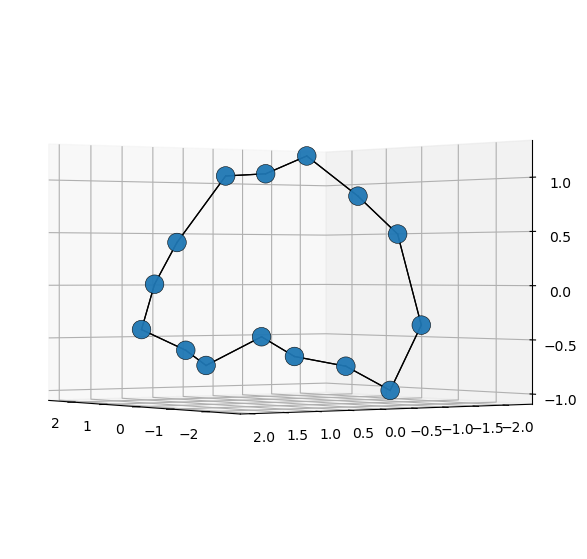

In [25]:
%matplotlib inline
# %matplotlib widget

# Raw plotting constants for this block
cycle_raw_elev = 0
cycle_raw_azim = 145
cycle_raw_roll = 0
cycle_raw_axis_permutation = (0, 1, 2)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

_xi, _yi, _zi = cycle_raw_axis_permutation
ax.scatter(
    cycle_reduced_embeddings[:, _xi],
    cycle_reduced_embeddings[:, _yi],
    cycle_reduced_embeddings[:, _zi],
    s=180,
    alpha=0.95,
    edgecolor='black',
    linewidth=0.4,
)

for u, v in cycle_edge_list:
    ax.plot(
        [cycle_reduced_embeddings[u, _xi], cycle_reduced_embeddings[v, _xi]],
        [cycle_reduced_embeddings[u, _yi], cycle_reduced_embeddings[v, _yi]],
        [cycle_reduced_embeddings[u, _zi], cycle_reduced_embeddings[v, _zi]],
        color='k',
        linewidth=0.9,
    )

ax.view_init(elev=float(cycle_raw_elev), azim=float(cycle_raw_azim), roll=float(cycle_raw_roll))
plt.title("")
plt.show()


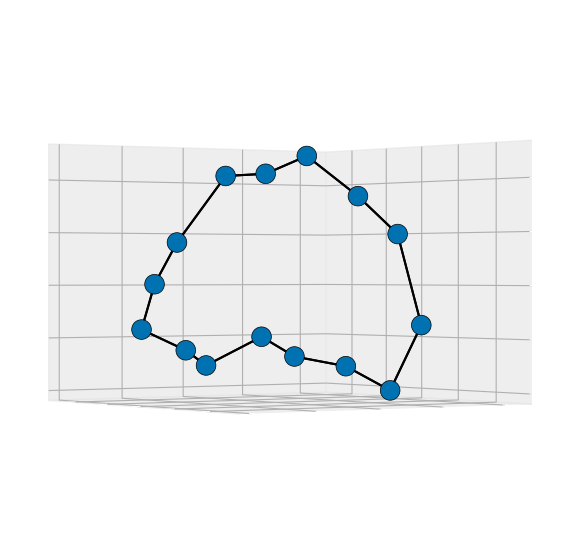

In [26]:
# Styled plotting constants for this block
cycle_styled_view = {"elev": cycle_raw_elev, "azim": cycle_raw_azim, "roll": cycle_raw_roll}
cycle_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_reduced_embeddings,
    cycle_edge_list,
    title="",
    view=cycle_styled_view,
    root_node_index=cycle_root_node_index,
    axis_permutation=cycle_styled_axis_permutation,
);


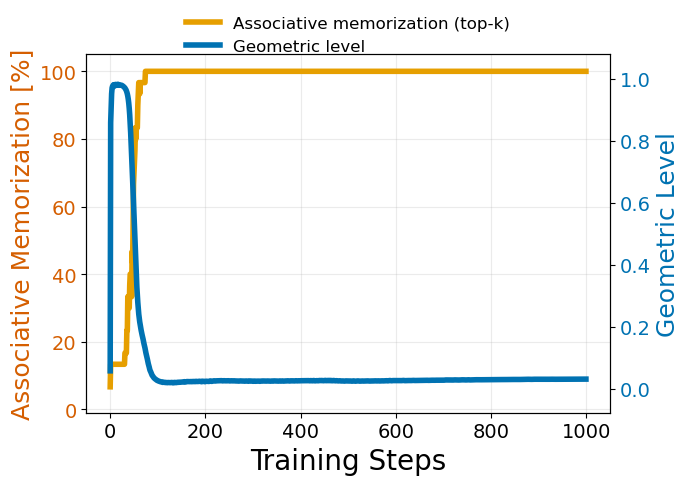

In [27]:
# Line-plot constants for this block
cycle_line_plot_title = ""

cycle_curve_steps, cycle_curve_associative, cycle_curve_geometric = compute_associative_geometric_curves(
    cycle_embedding_history,
    cycle_topk_recovery_history,
    cycle_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=cycle_curve_steps,
    associative_scores=cycle_curve_associative,
    geometric_scores=cycle_curve_geometric,
    title=cycle_line_plot_title,
);


## 4) Tiny Irregular (N=16, Fixed Edge List)


In [28]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_transformer_section_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)


In [29]:
irregular_seed = 7

irregular_train_from_scratch = True
irregular_checkpoint_path = ""
irregular_embedding_history_path = ""
irregular_topk_history_path = ""
irregular_dataset_overwrite = False

irregular_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.05,
    "--edge_memorization_epochs": 1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0.005,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 64,
    "--optimizer_weight_decay": 0.001,
    "--disable_edge_memorization_lr_decay": True,
    "--dropout_rate": 0.,
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,

    "--graph_type": "irregular",
    "--path_length": 5,
    "--total_nodes": 16,
    "--irregular_edge_count": 20,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
}


In [30]:
irregular_context = build_transformer_section_context(
    irregular_cli_config,
    seed=irregular_seed,
    dataset_overwrite=irregular_dataset_overwrite,
)

irregular_resolved_checkpoint_path = train_or_load_edge_model(
    irregular_context,
    train_from_scratch=irregular_train_from_scratch,
    checkpoint_path=irregular_checkpoint_path,
)

print("Run name:", irregular_context.args.run_name)
print("Checkpoint:", irregular_resolved_checkpoint_path)
print("Pretrain file:", irregular_context.pretrain_path)
print("Train file:", irregular_context.train_path)
print("Test file:", irregular_context.test_path)
print("Archived checkpoint:", irregular_context.checkpoint_path)
print("Embedding history pickle:", irregular_context.embedding_history_path)
print("Top-k pickle:", irregular_context.topk_history_path)
print("Manifest:", irregular_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
data/datasets/in_weights_graphs/irregular_graphs_randomized/irregular_graph_nodes_16_edges_20_sd_00_fb_11_pretrain.txt
data/datasets/in_weights_graphs/irregular_graphs_randomized/irregular_graph_nodes_16_edges_20_sd_00_fb_11_train_12.txt
data/datasets/in_weights_graphs/irregular_graphs_randomized/irregular_graph_nodes_16_edges_20_sd_00_fb_11_test_4.txt
Loaded 40 edge memorization pairs from data/datasets/in_weights_graphs/irregular_graphs_randomized/irregular_graph_nodes_16_edges_20_sd_00_fb_11_pretrain.txt
Equal sequence lengths!
Edge memorization dataset size: 40
Edge dataset tokens -> prefix=2, target=1
Loaded 12 path finetuning pairs from data/datasets/in_weights_graphs/irregular_graphs_randomized/irregular_graph_nodes_16_edges_20_sd_00_fb_11_train_12.txt
Equal sequence lengths!
Path finetuning dataset size: 12
Path dataset toke

Edge Epoch 1/1000 | Loss: 3.2219 | Acc: 7.50%: 100%|██████████| 1/1 [00:00<00:00, 69.00it/s]
Edge Epoch 2/1000 | Loss: 2.8152 | Acc: 7.50%: 100%|██████████| 1/1 [00:00<00:00, 87.35it/s]
Edge Epoch 3/1000 | Loss: 7.4482 | Acc: 7.50%: 100%|██████████| 1/1 [00:00<00:00, 88.60it/s]
Edge Epoch 4/1000 | Loss: 7.7908 | Acc: 5.00%: 100%|██████████| 1/1 [00:00<00:00, 111.55it/s]
Edge Epoch 5/1000 | Loss: 3.2529 | Acc: 7.50%: 100%|██████████| 1/1 [00:00<00:00, 85.11it/s]
Edge Epoch 6/1000 | Loss: 5.2633 | Acc: 7.50%: 100%|██████████| 1/1 [00:00<00:00, 112.20it/s]
Edge Epoch 7/1000 | Loss: 5.2188 | Acc: 7.50%: 100%|██████████| 1/1 [00:00<00:00, 112.13it/s]
Edge Epoch 8/1000 | Loss: 4.3111 | Acc: 7.50%: 100%|██████████| 1/1 [00:00<00:00, 123.89it/s]
Edge Epoch 9/1000 | Loss: 4.7727 | Acc: 5.00%: 100%|██████████| 1/1 [00:00<00:00, 101.47it/s]
Edge Epoch 10/1000 | Loss: 4.6626 | Acc: 7.50%: 100%|██████████| 1/1 [00:00<00:00, 114.70it/s]
Edge Epoch 11/1000 | Loss: 3.8246 | Acc: 7.50%: 100%|██████████


Edge accuracy improved to 40.00%. Saved best checkpoint: experiment_logs/in_weights/in_weights_irregular-n16-e20_gpt-L1-D64-H1_tiny_irregular_feedforward_plain_edge_bs2048x2048-lr0p05x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101144/checkpoints/in_weights_irregular-n16-e20_gpt-L1-D64-H1_tiny_irregular_feedforward_plain_edge_bs2048x2048-lr0p05x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101144_edge_memorization_best.pt


Edge Epoch 1000/1000 | Loss: 0.9418 | Acc: 40.00%: 100%|██████████| 1/1 [00:00<00:00, 89.23it/s]



Edge memorization complete. Best edge accuracy: 40.00%
Run name: in_weights_irregular-n16-e20_gpt-L1-D64-H1_tiny_irregular_feedforward_plain_edge_bs2048x2048-lr0p05x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101144
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/saved_artifacts/checkpoints/irregular/in_weights_irregular-n16-e20_gpt-L1-D64-H1_tiny_irregular_feedforward_plain_edge_bs2048x2048-lr0p05x0p005_tl0-rev0-sd00-fb11-task1-split0_20260324-101144_edge_memorization_final.pt
Pretrain file: data/datasets/in_weights_graphs/irregular_graphs_randomized/irregular_graph_nodes_16_edges_20_sd_00_fb_11_pretrain.txt
Train file: data/datasets/in_weights_graphs/irregular_graphs_randomized/irregular_graph_nodes_16_edges_20_sd_00_fb_11_train_12.txt
Test file: data/datasets/in_weights_graphs/irregular_graphs_randomized/irregular_graph_nodes_16_edges_20_sd_00_fb_11_test_4.txt
Archived checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_n

In [39]:
irregular_eval_metrics = evaluate_edge_and_path(irregular_context)

print_evaluation_report("Tiny Irregular", irregular_eval_metrics)


Edge Memorization | Loss: 0.9395 | Acc: 40.00%: 100%|██████████| 1/1 [00:00<00:00, 24.89it/s]


Edge Memorization | Loss: 0.9395 | Acc: 40.00%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 76.50it/s]

Tiny Irregular | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [32]:
irregular_node_embeddings, irregular_edge_list, irregular_root_node_index = collect_embeddings_and_edges(irregular_context)

irregular_embedding_history, irregular_topk_recovery_history = load_analysis_histories(
    irregular_context,
    irregular_edge_list,
    embedding_history_path=irregular_embedding_history_path,
    topk_history_path=irregular_topk_history_path,
)

if not irregular_embedding_history:
    irregular_embedding_history = {0: irregular_node_embeddings}
if not irregular_topk_recovery_history:
    irregular_topk_recovery_history = {0: irregular_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", irregular_node_embeddings.shape)
print("Number of edges:", len(irregular_edge_list))
print("Root node index:", irregular_root_node_index)
print("Embedding history steps:", len(irregular_embedding_history))
print("Top-k history steps:", len(irregular_topk_recovery_history))


Node embedding shape: (16, 64)
Number of edges: 40
Root node index: None
Embedding history steps: 1000
Top-k history steps: 1000


In [33]:
# Reduction config for this block (kept local to reduction stage)
irregular_use_umap = False
irregular_reduction_dim = 4
irregular_umap_n_neighbors = 8
irregular_umap_min_dist = 0.3

irregular_reduced_full, irregular_reduced_embeddings = reduce_embeddings_for_plot(
    irregular_node_embeddings,
    use_umap=irregular_use_umap,
    reduction_dim=irregular_reduction_dim,
    seed=irregular_seed,
    umap_n_neighbors=irregular_umap_n_neighbors,
    umap_min_dist=irregular_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
irregular_reduced_embeddings = irregular_reduced_full[:, :3]
print("Reduced full shape:", irregular_reduced_full.shape)
print("Reduced xyz shape:", irregular_reduced_embeddings.shape)


Reduced full shape: (16, 4)
Reduced xyz shape: (16, 3)


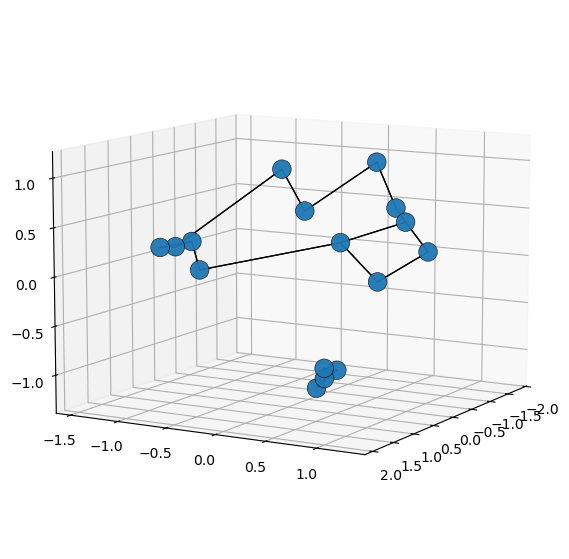

In [34]:
%matplotlib inline
# %matplotlib widget

# Raw plotting constants for this block
irregular_raw_elev = 10
irregular_raw_azim = 30
irregular_raw_roll = 0
irregular_raw_axis_permutation = (0, 1, 2)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

_xi, _yi, _zi = irregular_raw_axis_permutation
ax.scatter(
    irregular_reduced_embeddings[:, _xi],
    irregular_reduced_embeddings[:, _yi],
    irregular_reduced_embeddings[:, _zi],
    s=180,
    alpha=0.95,
    edgecolor='black',
    linewidth=0.4,
)

for u, v in irregular_edge_list:
    ax.plot(
        [irregular_reduced_embeddings[u, _xi], irregular_reduced_embeddings[v, _xi]],
        [irregular_reduced_embeddings[u, _yi], irregular_reduced_embeddings[v, _yi]],
        [irregular_reduced_embeddings[u, _zi], irregular_reduced_embeddings[v, _zi]],
        color='k',
        linewidth=0.9,
    )

ax.view_init(elev=float(irregular_raw_elev), azim=float(irregular_raw_azim), roll=float(irregular_raw_roll))
plt.title("")
plt.show()


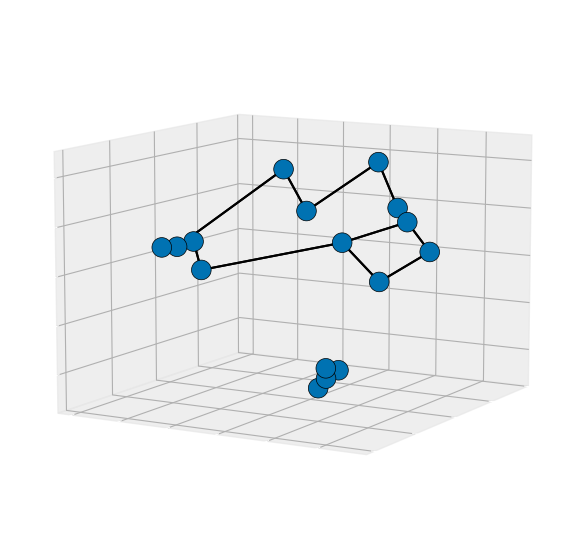

In [35]:
# Styled plotting constants for this block
irregular_styled_view = {"elev": irregular_raw_elev, "azim": irregular_raw_azim, "roll": irregular_raw_roll}
irregular_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    irregular_reduced_embeddings,
    irregular_edge_list,
    title="",
    view=irregular_styled_view,
    root_node_index=irregular_root_node_index,
    axis_permutation=irregular_styled_axis_permutation,
);


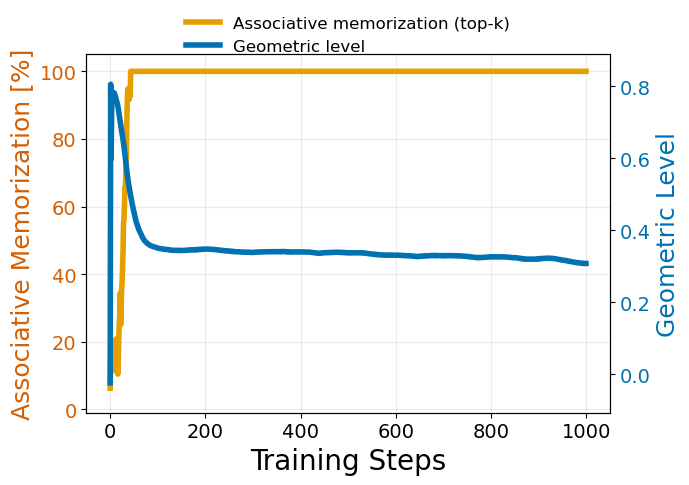

In [36]:
# Line-plot constants for this block
irregular_line_plot_title = ""

irregular_curve_steps, irregular_curve_associative, irregular_curve_geometric = compute_associative_geometric_curves(
    irregular_embedding_history,
    irregular_topk_recovery_history,
    irregular_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=irregular_curve_steps,
    associative_scores=irregular_curve_associative,
    geometric_scores=irregular_curve_geometric,
    title=irregular_line_plot_title,
);
